# Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().parent.parent
print("✅ Evaluation setup complete")

✅ Evaluation setup complete


# Load Model and Data

In [4]:
# Load best model
model_path = PROJECT_ROOT / 'models/checkpoints/catboost_model.pkl'
model = joblib.load(model_path)
print(f"✅ Model loaded: {type(model).__name__}")

# Load test data
df = pd.read_parquet(PROJECT_ROOT / 'data/features/engineered_features.parquet')
feature_cols = [col for col in df.columns if col not in ['target']]
X = df[feature_cols].values
y = df['target'].values

split_idx = int(len(X) * 0.8)
X_test, y_test = X[split_idx:], y[split_idx:]

✅ Model loaded: CatBoostRegressor


# Make Predictions

In [5]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction_acc = (np.sign(y_test) == np.sign(y_pred)).mean()

print("\n📊 Model Performance:")
print(f"   RMSE: {rmse:.4f} ({rmse*100:.2f}%)")
print(f"   MAE: {mae:.4f} ({mae*100:.2f}%)")
print(f"   R²: {r2:.4f}")
print(f"   Direction Accuracy: {direction_acc:.2%}")


📊 Model Performance:
   RMSE: 0.0317 (3.17%)
   MAE: 0.0261 (2.61%)
   R²: -1.6092
   Direction Accuracy: 44.99%


# Visualization

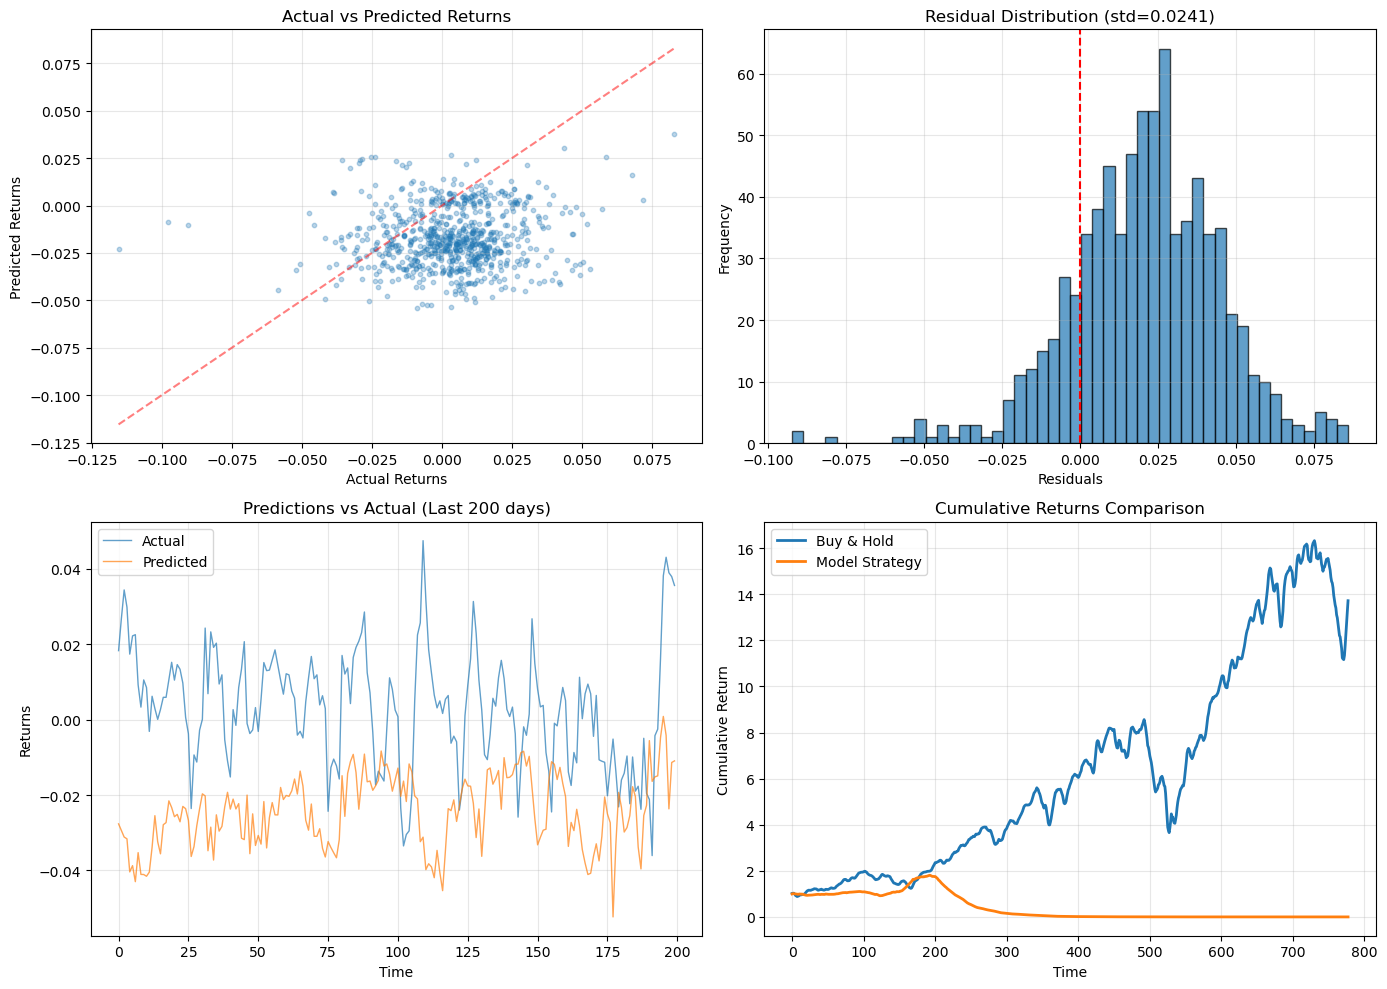

✅ Evaluation plots saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)
axes[0,0].set_xlabel('Actual Returns')
axes[0,0].set_ylabel('Predicted Returns')
axes[0,0].set_title('Actual vs Predicted Returns')
axes[0,0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Residuals')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title(f'Residual Distribution (std={residuals.std():.4f})')
axes[0,1].grid(True, alpha=0.3)

# Time series comparison
axes[1,0].plot(y_test[-200:], label='Actual', alpha=0.7, linewidth=1)
axes[1,0].plot(y_pred[-200:], label='Predicted', alpha=0.7, linewidth=1)
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Returns')
axes[1,0].set_title('Predictions vs Actual (Last 200 days)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Cumulative returns
cumulative_actual = (1 + y_test).cumprod()
cumulative_pred = (1 + y_pred).cumprod()
axes[1,1].plot(cumulative_actual, label='Buy & Hold', linewidth=2)
axes[1,1].plot(cumulative_pred, label='Model Strategy', linewidth=2)
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Cumulative Return')
axes[1,1].set_title('Cumulative Returns Comparison')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'visualizations/plots/evaluation_results.png', dpi=150)
plt.show()
print("✅ Evaluation plots saved")